In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio
from glob import glob
import pathlib

## Completando informações dos poços

In [2]:
wells_info = pd.read_csv("well_coords.csv", index_col='id')
wells_info['Well'] = wells_info['Well'].apply(lambda x: x.upper())
wells_info.head()

,Well,x_coord,y_coord
id,,,
0,2-ANP-1-RJS,677,1722
1,3-BRSA-1064-RJS,652,1114
2,3-BRSA-1184-RJS,855,1230
3,3-BRSA-1195-RJS,1041,2322
4,7-BUZ-10-RJS,415,392


In [3]:
len(wells_info)

37

In [4]:
def get_las_files_from(dir_path:str) -> list:
    """
    Gets all .las files from dir_path. dir_path may be a regex or str.
    Returns a list with every file name found
    """
    full_filter = f"{str(dir_path)}*.las"
    return list(glob(full_filter))

In [5]:
target_dir_for_las_search = 'pocos_ANP/*/'
well_las_files = get_las_files_from(target_dir_for_las_search)

In [19]:
def get_well_file_name(file_path:str):
    return pathlib.Path(file_path).stem.upper().split('_')[0]

def filter_files_with_target_names(all_file_names:list, filter_files_names:list) -> list:
    """
    Filter all files with name in filter_files_names.
    Also, it first gets the uppercase stemmed file name and then splits it for '_'.

    Example: 
    stem(mY-file-Name_123.las).upper().split('_')[0] == MY-FILE-NAME
    
    """
    return list(filter(lambda x: get_well_file_name(x) in filter_files_names, all_file_names))

def filter_files_not_with_names(all_file_names:list, filter_files_names:list) -> list:
    return list(filter(lambda x: get_well_file_name(x) not in filter_files_names, all_file_names))

def read_well(well_file:str):
    return lasio.read(well_file)

def get_wells_y_limits_per_file(well_files:list) -> dict:
    wells_y_limits_dict = dict()
    for well_file in well_files:
        y_limits = tuple(read_well(well_file).df().index.values[[0,-1]].tolist())
        wells_y_limits_dict[get_well_file_name(well_file)] = y_limits
    return wells_y_limits_dict

def get_min_y_limit_for_file_name(file_path, limit_dict) -> tuple:
    return limit_dict[get_well_file_name(file_path)][0]

def get_max_y_limit_for_file_name(file_path, limit_dict) -> tuple:
    return limit_dict[get_well_file_name(file_path)][1]

def complete_wells_info_with_y_limits(wells_info:pd.DataFrame, wells_y_limits:dict) -> pd.DataFrame:
    wells_info_copy = wells_info
    wells_info_copy['min_y'] = wells_info['Well'].apply(
                                        lambda x: get_min_y_limit_for_file_name(x, wells_y_limits))
    wells_info_copy['max_y'] = wells_info['Well'].apply(
                                        lambda x: get_max_y_limit_for_file_name(x, wells_y_limits))
    
    return wells_info_copy

def complete_well_info_with_y_limits_from_las_files(wells_info:pd.DataFrame,
                                                    well_las_files:list) -> pd.DataFrame:
    wells_names = wells_info['Well'].to_list()
    matching_well_las_files = filter_files_with_target_names(well_las_files, wells_names)
    wells_y_limits_dict = get_wells_y_limits_per_file(matching_well_las_files)
    wells_info = complete_wells_info_with_y_limits(wells_info, wells_y_limits_dict)
    return wells_info

In [20]:
full_wells_info = complete_well_info_with_y_limits_from_las_files(wells_info, well_las_files)

In [21]:
full_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y
id,,,,,
0,2-ANP-1-RJS,677,1722,5400.0,5880.0
1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0
2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0
3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0
4,7-BUZ-10-RJS,415,392,5300.0,5780.0


In [22]:
full_wells_info.isna().sum()

Well       0
x_coord    0
y_coord    0
min_y      0
max_y      0
dtype: int64

In [23]:
filter_files_not_with_names(well_las_files, full_wells_info['Well'].to_list())

['pocos_ANP\\convertidas no projeto\\3-BRSA-1053-RJS.las']

Aparentemente, não temos os dados de coordenadas para esse poço acima.

In [24]:
# wells = [np.sort(lasio.read(x).df().index.values)[[0,-1]].tolist() for x in glob('pocos_ANP/*/*.las')]
# wells = np.array(sorted(wells))

In [56]:
def get_well_type_by_y_limits(well_row):
    max_y = well_row['max_y']
    min_y = well_row['min_y']
    if max_y - min_y >= 2000:
        return 'complete'

    if max_y < 4000:
        return 'top'
    
    return 'bottom'

In [57]:
full_wells_info['type'] = full_wells_info.apply(lambda x: get_well_type_by_y_limits(x), axis=1)

In [58]:
full_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y,type
id,,,,,,
0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom
1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom
2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom
3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom
4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom


In [59]:
bottom_wells = full_wells_info[full_wells_info['type'] == 'bottom']
top_wells = full_wells_info[full_wells_info['type'] == 'top']
complete_wells = full_wells_info[full_wells_info['type'] == 'complete']

In [60]:
full_wells_info['type'].value_counts()

type
bottom      17
complete    16
top          4
Name: count, dtype: int64

In [127]:
target_file = "wells_info_completed.csv"
full_wells_info.to_csv(target_file)

## Visualizando a distribuição dos poços por classe

In [123]:
def plot_full_y_range(x, ystart, ystop):
    color = 'r'
    timelines(x, ystart, ystop, 'range base', color=color)

def timelines(x, ystart, ystop, label, color='b'):
    """Plot timelines at x from ystart to ystop with given color."""
    plt.vlines(x, ystart, ystop, color, lw=4, zorder=3, label=label)
    plt.hlines(ystart, x+0.3, x-0.3, color, lw=2, zorder=3)
    plt.hlines(ystop, x+0.3, x-0.3, color, lw=2, zorder=3)

def plot_horizontal_line(min_x, max_x, y, label=True):
    if label:
        plt.plot([min_x, max_x], [y, y], color="grey", ls="--", zorder=0, label='Faixa alvo')
    else:
        plt.plot([min_x, max_x], [y, y], color="grey", ls="--", zorder=0)

def plot_wells_y_limits_by_class(wells_by_class:dict, color_dict:dict):

    num_wells = 0
    for key, well_df in wells_by_class.items():
        num_wells += len(well_df)

    #This adds one up to the curr_x_range
    plot_full_y_range(0, 2000, 8000)

    class_order = ('complete', 'top', 'bottom')

    curr_x_range = None
    x_offset = 0
    for well_class in class_order:
        target_wells = wells_by_class[well_class]
        ordered_wells = target_wells.sort_values(by='min_y', ascending=True)
        curr_x_range = np.arange(len(target_wells)) + x_offset + 1
        color = color_dict[well_class]
        timelines(curr_x_range, target_wells['min_y'], target_wells['max_y'], well_class, color)
        x_offset = curr_x_range.max()

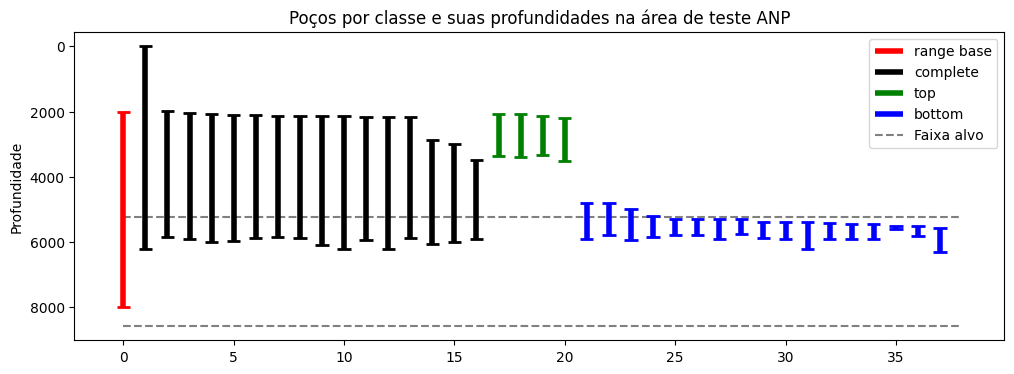

In [134]:
fig = plt.figure(figsize=(12,4))

wells_by_class_dict = {
    'complete': complete_wells,
    'top': top_wells,
    'bottom': bottom_wells
}

color_dict = {'complete': 'black', 'top':'green', 'bottom':'blue'}

plot_wells_y_limits_by_class(wells_by_class_dict, color_dict)
plot_horizontal_line(0, num_wells+1, 5246, label=True)
plot_horizontal_line(0, num_wells+1, 8583, label=False)

plt.gca().invert_yaxis()
plt.ylabel('Profundidade')
plt.title("Poços por classe e suas profundidades na área de teste ANP")
plt.legend()
plt.savefig("pocos_limites_z.png")
plt.show()

2000 e 8000 m, amostradas a cada 5 m

In [132]:
def plot_well_type(axs, well_type, wells_df, color, point_size=5):
    axs.scatter(wells_df['x_coord'], wells_df['y_coord'], s=point_size, 
            c=color_dict[well_type])
    axs.set_title(well_type)

def plot_wells_coords_by_class_dict(wells_dict, color_dict, filename=None):
    # plt.figure(figsize=(6, 8))
    fig, axs = plt.subplots(2,2, sharex=True, sharey=True, figsize=(6, 8))

    fig.suptitle("Poços na área de teste da ANP")

    point_size = 8
    # Plot all wells
    for well_type, wells_df in wells_dict.items():
        axs[0, 0].scatter(wells_df['x_coord'], wells_df['y_coord'], s=point_size, 
            label=well_type, c=color_dict[well_type])
        axs[0, 0].set_title("Todos os poços")
    
    plot_well_type(axs[0, 1], 'complete', wells_dict['complete'], color_dict['complete'], point_size)
    plot_well_type(axs[1, 0], 'bottom', wells_dict['bottom'], color_dict['bottom'], point_size)
    plot_well_type(axs[1, 1], 'top', wells_dict['top'], color_dict['top'], point_size)

    y_lim = 2898
    x_lim = 1344
    for ax in axs.flat:
        ax.set(xlabel='x-coord', ylabel='y-coord')
        ax.set_xlim([0, x_lim])
        ax.set_ylim([0, y_lim])

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()

    # plt.title("Poços na área de teste ANP")
    # plt.xlabel("x")
    # plt.ylabel("y")
    # plt.ylim(0, 2898)
    # plt.xlim(0, 1344)
    plt.legend()
    if filename:
        plt.savefig(filename)
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


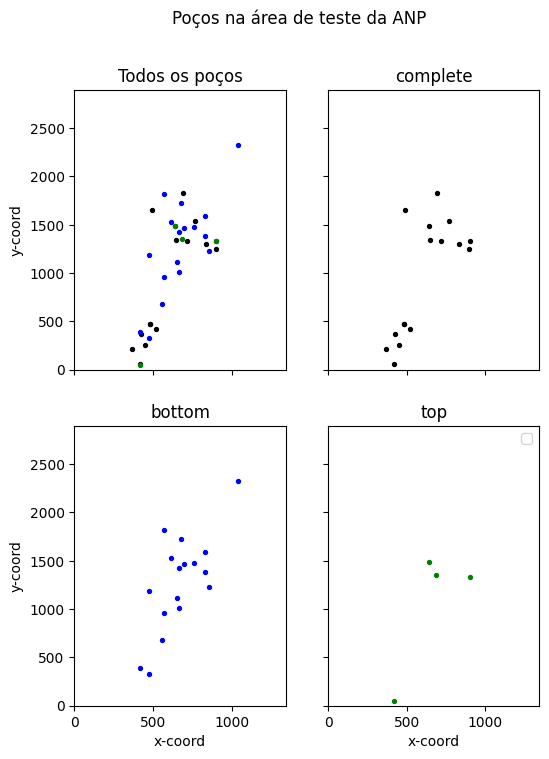

In [133]:
plot_wells_coords_by_class_dict(wells_by_class_dict, color_dict, filename='pocos_dist.png')

## Ajustando o range dos poços de acordo com a amostragem feita

O arquivo Franco_Florin.npy fornecido não possui range em z de 2000 a 8000 (6001 valores), mas sim, de 0 a 1200 (1201 valores). Isso mostra que a amostragem de porosidade foi realizada a cada 5 metros.

Dessa forma, vou criar colunas adicionais no wells_info_completed que indique os limites do range do poço de acordo com essa amostragem.

In [4]:
target_file = "wells_info_completed.csv"
full_wells_info = pd.read_csv(target_file)

In [5]:
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type
0,0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom
1,1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom
2,2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom
3,3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom
4,4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom


In [8]:
full_wells_info['min_y_adjusted'] = full_wells_info['min_y'] / 5
full_wells_info['max_y_adjusted'] = full_wells_info['max_y'] / 5


In [9]:
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
0,0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom,1080.0,1176.0
1,1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom,1000.0,1186.0
2,2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom,1080.0,1180.0
3,3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom,1090.0,1180.0
4,4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom,1060.0,1156.0


## Arredondando os valores das coordenadas

In [18]:
full_wells_info = full_wells_info.astype({'max_y':'int32', 'min_y':'int32', 
                        'min_y_adjusted':'int32', 'max_y_adjusted':'int32'})
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
0,0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176
1,1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186
2,2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180
3,3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180
4,4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156


In [19]:
target_file = "wells_info_completed.csv"
full_wells_info.to_csv(target_file)